<a href="https://colab.research.google.com/github/aavarela/SPBD_Labs/blob/main/projeto2/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 2
This work was carried out by Afonso Varela (73544) and Gonçalo Dionísio (73638), with the help of Google Gemini 3 Pro (AI agent).

#Environment configuration

In [2]:
#@title Install and launch Kafka
%%bash
# Download and Extract Kafka if it doesn't exist
KAFKA_VERSION=3.7.2
KAFKA=kafka_2.12-$KAFKA_VERSION

if [ ! -d "$KAFKA" ]; then
    echo "Kafka not found. Downloading $KAFKA..."
    wget -q -O /tmp/$KAFKA.tgz https://dlcdn.apache.org/kafka/$KAFKA_VERSION/$KAFKA.tgz
    tar -xzf /tmp/$KAFKA.tgz
    rm /tmp/$KAFKA.tgz
    echo "Download complete."
fi

# Kill any existing Kafka processes
pkill -9 -f kafka || true

# Clear out temporary storage
rm -rf /tmp/kafka-logs /tmp/kraft-combined-logs

# Format and Start
wget -q -O $KAFKA/config/server1.properties - https://github.com/smduarte/spbd-2526/raw/refs/heads/main/docs/labs/projs/server1.properties
UUID=`$KAFKA/bin/kafka-storage.sh random-uuid`
$KAFKA/bin/kafka-storage.sh format -t $UUID -c $KAFKA/config/server1.properties

# Start Kafka
$KAFKA/bin/kafka-server-start.sh -daemon $KAFKA/config/server1.properties

# Wait for quorum
echo "Waiting for Kafka to start..."
sleep 15

# Verify server is running and listening in port 9092
lsof -i :9092

Kafka not found. Downloading kafka_2.12-3.7.2...
Download complete.
Formatting /tmp/kraft-combined-logs with metadata.version 3.7-IV4.
Waiting for Kafka to start...
COMMAND  PID USER   FD   TYPE DEVICE SIZE/OFF NODE NAME
java    1798 root  173u  IPv6  33727      0t0  TCP *:9092 (LISTEN)


In [3]:
#@title Install pyspark 3.5.7 for compatibility with spark-sql-kafka 3.5.7
!pip uninstall -y dataproc-spark-connect
!pip uninstall -y pyspark
!pip install pyspark==3.5.7

Found existing installation: dataproc-spark-connect 1.0.1
Uninstalling dataproc-spark-connect-1.0.1:
  Successfully uninstalled dataproc-spark-connect-1.0.1
Found existing installation: pyspark 4.0.1
Uninstalling pyspark-4.0.1:
  Successfully uninstalled pyspark-4.0.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.4/317.4 MB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 21.5 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.7-py2.py3-none-any.whl size=317907716 sha256=5eac7c6c62aac65c61684057372608a6879abbba8915592837378c0aa64727b6
  Stored in directory: /root/.cache/pip/wheels/f2/d3/02/10ad17f2eeb2cb9c800e320c8ca9ac87d0df8fe3adb8af7e95
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9


In [4]:
#@title Download 1% sample
!wget -q -O taxi_rides_1pc.csv.gz https://www.dropbox.com/scl/fi/v8ei5laqcalrx30z3lsty/taxi_rides_1pc.csv.gz?rlkey=q1lq7l56c4j97h9kymsdroau5&st=iurdwnwj&dl=0

In [33]:
#@title Start Kafka publisher and verify if Kafka is streaming
import subprocess
import time
import os

# Install dependencies
!pip --quiet install kafka-python dataclasses

# Setup paths and files
KAFKA_PATH = "/content/kafka_2.12-3.7.2"
if not os.path.exists('kafka-publisher.py'):
    !wget -q -O kafka-publisher.py https://raw.githubusercontent.com/smduarte/spbd-2526/refs/heads/main/docs/labs/projs/kafka-publisher.py

# Start publisher (Redirecting logs for debugging). Events are published 60x
# faster than realtime relative to the original timestamps
print("Starting Kafka publisher...")
!nohup python kafka-publisher.py --topic taxis_json --speedup 60 --filename taxi_rides_1pc.csv.gz > publisher.log 2>&1 &

# Modern Health Check Loop (Replaces GetOffsetShell)
print("Verifying data stream (Waiting for offsets > 0)...")
data_detected = False

for i in range(20): # Try for ~100 seconds
    try:
        # Kafka 3.x tool to get the latest offset (--time -1 means 'latest')
        cmd = [
            f"{KAFKA_PATH}/bin/kafka-get-offsets.sh",
            "--bootstrap-server", "localhost:9092",
            "--topic", "taxis_json",
            "--time", "-1"
        ]

        output = subprocess.check_output(cmd, stderr=subprocess.STDOUT).decode()

        # Output format: taxis_json:0:OFFSETS
        if ":" in output:
            # Extract the offset (the last number after the last colon)
            current_offset = int(output.strip().split(':')[-1])

            if current_offset > 0:
                print(f"✅ Success! Kafka is streaming. Current offset: {current_offset}")
                data_detected = True
                break
    except Exception as e:
        # Handle the case where the topic isn't created yet
        # or the server is still warming up
        pass

    print(f"Waiting for data... ({i+1}/20)")
    time.sleep(5)

if not data_detected:
    print("❌ ERROR: No data detected. Showing last 10 lines of publisher.log:")
    !tail -n 10 publisher.log

Starting Kafka publisher...
Verifying data stream (Waiting for offsets > 0)...
✅ Success! Kafka is streaming. Current offset: 82276


# Data stream preparation

In [46]:
#@title Prepare data streams
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

spark = SparkSession \
    .builder \
    .appName('Kafka Spark Structured Streaming Example') \
    .config('spark.jars.packages', 'org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.7') \
    .getOrCreate()

lines = spark \
  .readStream \
  .format('kafka') \
  .option('kafka.bootstrap.servers', 'localhost:9092') \
  .option('subscribe', 'taxis_json') \
  .option('startingOffsets', 'earliest') \
  .load() \
  .selectExpr('CAST(value AS STRING)')

# Define a StructType named taxi_ride_schema
taxi_ride_schema = StructType([
    StructField("medallion", StringType(), True),
    StructField("pickup_datetime", TimestampType(), True),
    StructField("dropoff_datetime", TimestampType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("pickup_latitude", DoubleType(), True),
    StructField("pickup_longitude", DoubleType(), True),
    StructField("dropoff_latitude", DoubleType(), True),
    StructField("dropoff_longitude", DoubleType(), True),
    StructField("pickup_grid_x", IntegerType(), True),
    StructField("pickup_grid_y", IntegerType(), True),
    StructField("dropoff_grid_x", IntegerType(), True),
    StructField("dropoff_grid_y", IntegerType(), True)
])

# Parsing and initial processing
parsed_stream = lines.withColumn("parsed_value", from_json(col("value"), taxi_ride_schema))
structured_stream = parsed_stream.select(col("parsed_value.*"))

MIN_LON = -74.916578
MAX_LAT = 41.47718278
LON_DELTA = 0.005986
LAT_DELTA = 0.004491556

processed_stream = structured_stream \
    .withColumn("pickup_grid_x", floor((MAX_LAT - col("pickup_latitude")) / LAT_DELTA)) \
    .withColumn("pickup_grid_y", floor((col("pickup_longitude") - MIN_LON) / LON_DELTA)) \
    .withColumn("dropoff_grid_x", floor((MAX_LAT - col("dropoff_latitude")) / LAT_DELTA)) \
    .withColumn("dropoff_grid_y", floor((col("dropoff_longitude") - MIN_LON) / LON_DELTA)) \
    .filter(
        (col("pickup_latitude").isNotNull()) & (col("pickup_longitude").isNotNull()) & \
        (col("dropoff_latitude").isNotNull()) & (col("dropoff_longitude").isNotNull()) & \
        (col("pickup_grid_x").between(0, 299)) & (col("pickup_grid_y").between(0, 299)) & \
        (col("dropoff_grid_x").between(0, 299)) & (col("dropoff_grid_y").between(0, 299)) & \
        (col("trip_distance") > 0)
    ) \
    .withColumn("trip_profit", col("fare_amount") + col("tip_amount")) \
    .withColumn("pickup_hour", hour(col("pickup_datetime"))) \
    .withColumn("time_of_day",
        when((col("pickup_hour") >= 0) & (col("pickup_hour") <= 5), "Night (0-5am)")
        .when((col("pickup_hour") >= 6) & (col("pickup_hour") <= 11), "Morning (6-11am)")
        .when((col("pickup_hour") >= 12) & (col("pickup_hour") <= 17), "Afternoon (12-5pm)")
        .otherwise("Evening (6-11pm)")
    )

# Watermarking
processed_stream_with_pickup_watermark = processed_stream.withWatermark("pickup_datetime", "10 minutes")
processed_stream_with_dropoff_watermark = processed_stream.withWatermark("dropoff_datetime", "10 minutes")

# Average profit per area stream
average_profit_per_area_stream = processed_stream_with_dropoff_watermark \
    .groupBy(
        window(col("dropoff_datetime"), "15 minutes"),
        col("pickup_grid_x"),
        col("pickup_grid_y"),
        col("time_of_day"),
    ) \
    .agg(
        avg("trip_profit").alias("average_trip_profit"),
        avg("trip_distance").alias("average_trip_distance"),
        count("*").alias("trip_count")
    )

# Empty taxis per area styream
dropoffs_for_empty = processed_stream_with_dropoff_watermark.select(
    col("medallion").alias("d_medallion"),
    col("dropoff_datetime").alias("d_time"),
    col("dropoff_grid_x").alias("d_grid_x"),
    col("dropoff_grid_y").alias("d_grid_y")
)

pickups_for_empty = processed_stream_with_pickup_watermark.select(
    col("medallion").alias("p_medallion"),
    col("pickup_datetime").alias("p_time"),
    col("pickup_grid_x").alias("p_grid_x"),
    col("pickup_grid_y").alias("p_grid_y")
)

empty_taxis_per_area_stream = dropoffs_for_empty.join(
    pickups_for_empty,
    expr("""
        d_medallion = p_medallion AND
        d_grid_x = p_grid_x AND
        d_grid_y = p_grid_y AND
        p_time BETWEEN d_time AND d_time + INTERVAL 30 MINUTES
    """),
    "leftOuter"
).filter(col("p_medallion").isNull()) \
 .groupBy(
    window(col("d_time"), "15 minutes"),
    col("d_grid_x"),
    col("d_grid_y")
).agg(count(col("d_medallion")).alias("empty_taxi_count"))

# Final joining and profitability calculation
area_profitability = average_profit_per_area_stream.join(
    empty_taxis_per_area_stream,
    (
        (average_profit_per_area_stream.window == empty_taxis_per_area_stream.window) &
        (average_profit_per_area_stream.pickup_grid_x == empty_taxis_per_area_stream.d_grid_x) &
        (average_profit_per_area_stream.pickup_grid_y == empty_taxis_per_area_stream.d_grid_y)
    ),
    "leftOuter"
).select(
    average_profit_per_area_stream.window,
    average_profit_per_area_stream.pickup_grid_x.alias("grid_x"),
    average_profit_per_area_stream.pickup_grid_y.alias("grid_y"),
    col("time_of_day"),
    col("average_trip_profit"),
    col("average_trip_distance"),
    col("trip_count"),
    coalesce(col("empty_taxi_count"), lit(0)).alias("empty_taxi_count")
).withColumn(
    "profitability",
    when(col("empty_taxi_count") == 0, 0.0)
    .otherwise(col("average_trip_profit") / col("empty_taxi_count"))
)

# Collect data from area profitability stream

In [ ]:
#@title OPTIONAL: test stream output
import time
import pandas as pd
from IPython.display import clear_output

# Stop any previous active queries
for q in spark.streams.active:
    q.stop()
print("All currently active streaming queries stopped.")

# Start a streaming query to collect the data
data_query = area_profitability \
    .writeStream \
    .outputMode("append") \
    .format("memory") \
    .queryName("collected_data") \
    .start()

print("Streaming query started.")

try:
    print("Monitoring 'collected_data' table (Ctrl+C to stop early)...")
    while True:
        # Query the memory sink
        result = spark.sql("SELECT count(*) as total, count(profitability) as with_val FROM collected_data").toPandas()

        clear_output(wait=True)
        print(f"Last updated: {time.ctime()}")
        print(f"Total rows collected: {result['total'][0]}")
        print(f"Rows with profitability values: {result['with_val'][0]}")

        if result['total'][0] > 0:
            print("\nPreview:")
            display(spark.sql("SELECT * FROM collected_data LIMIT 5").toPandas())

        time.sleep(10)
except KeyboardInterrupt:
    print("Monitoring stopped.")

In [73]:
import time
import pandas as pd

# Stop any previous active queries
for q in spark.streams.active:
    q.stop()
print("All currently active streaming queries stopped.")

# Start a streaming query to collect the data
data_query = area_profitability \
    .writeStream \
    .outputMode("append") \
    .format("memory") \
    .queryName("collected_data") \
    .start()

print("Streaming query started.")

print("Waiting to allow data to be collected.")
time.sleep(7200)

# Stop the streaming query
data_query.stop()

print("Streaming query stopped. Data collection complete.")

# Retrieve the collected data from the memory sink into a Pandas DataFrame
area_profitability_df = spark.sql("SELECT * FROM collected_data").toPandas()

# Display the collected data
print("Displaying the first 5 rows of the collected data:")
display(area_profitability_df.head())

print(f"Total rows in area_profitability data: {len(area_profitability_df)}")

All currently active streaming queries stopped.
Streaming query started.
Waiting to allow data to be collected.
Streaming query stopped. Data collection complete.
Displaying the first 5 rows of the collected data:


,window,grid_x,grid_y,time_of_day,average_trip_profit,average_trip_distance,trip_count,empty_taxi_count,profitability
0,"(2025-12-20 17:30:00, 2025-12-20 17:45:00)",155,156,Afternoon (12-5pm),11.822222,2.553016,63,49,0.241270
1,"(2025-12-20 17:00:00, 2025-12-20 17:15:00)",159,157,Afternoon (12-5pm),10.647356,2.304713,87,112,0.095066
2,"(2025-12-20 13:00:00, 2025-12-20 13:15:00)",157,164,Afternoon (12-5pm),5.500000,0.930000,1,1,5.500000
3,"(2025-12-20 15:45:00, 2025-12-20 16:00:00)",153,161,Afternoon (12-5pm),9.060000,1.953000,10,16,0.566250
4,"(2025-12-20 16:00:00, 2025-12-20 16:15:00)",163,160,Afternoon (12-5pm),10.000000,2.150000,1,3,3.333333


Total rows in area_profitability data: 9643


# Analysis

The primary objective of this work is to revisit the dataset, considering that in addition to the original archived data, we now have a real-time stream of current events.

We anticipate that the availability of the real-time stream will:

* Refine the analysis of the area’s profitability. The real-time knowledge will enable a more accurate reflection of profitability and empty taxi definitions.

* The analysis of the area’s profitability is one scenario that benefits from knowing what is happening **now**, compared to the archived dataset. This knowledge allows for the definition of time windows for drop-off and pickup events.

* The real-time knowledge introduces a notion of “now” that was absent when using the archived dataset. This enables analyses that involve events occurring *some minutes after* or *within some minutes*.

In the following sections, we will pose the same questions as in project 1 and assess any changes that might have occurred with the introduction of the real-time data streaming.

# Q1: Are some areas more profitable than others?

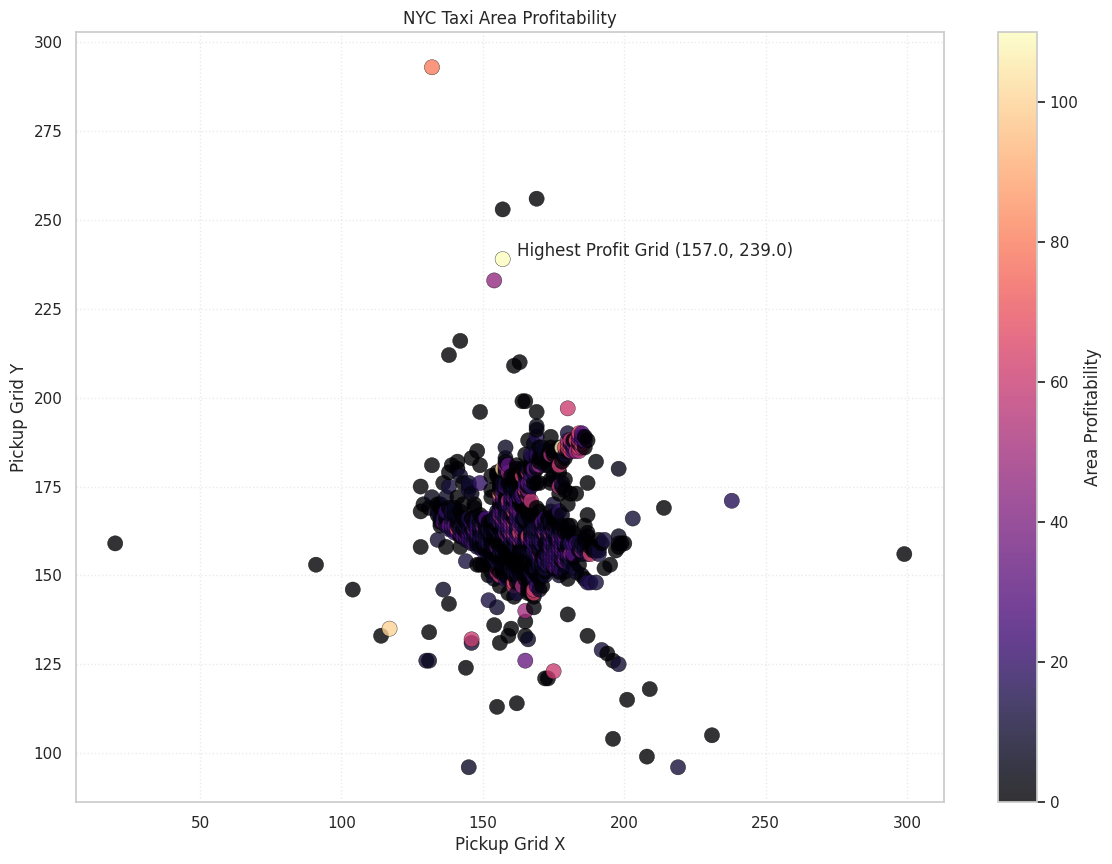

In [75]:
#@title Visualize the area profitability data
import matplotlib.pyplot as plt
import pandas as pd

geo_df = area_profitability_df.groupby(['grid_x', 'grid_y']).agg({
    'profitability': ['mean', 'max']
}).reset_index()
geo_df.columns = ['grid_x', 'grid_y', 'avg_profit', 'max_profit']

plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    geo_df['grid_x'],
    geo_df['grid_y'],
    c=geo_df['max_profit'],
    cmap='magma',
    s=120,
    marker='o',
    edgecolors='black',
    linewidth=0.3,
    alpha=0.8
)

plt.colorbar(scatter, label='Area Profitability')
plt.xlabel('Pickup Grid X')
plt.ylabel('Pickup Grid Y')
plt.title('NYC Taxi Area Profitability')
plt.grid(True, linestyle=':', alpha=0.4)

# Highlight the "Best" grid cell
best_row = geo_df.loc[geo_df['max_profit'].idxmax()]
plt.annotate(f"Highest Profit Grid ({best_row['grid_x']}, {best_row['grid_y']})",
              xy=(best_row['grid_x'], best_row['grid_y']),
              xytext=(best_row['grid_x']+5, best_row['grid_y']+1))

plt.show()

In [76]:
#@title Calculate key summary statistics of the area profitability data
# Select only the numerical columns for a cleaner summary
stats_cols = ['profitability']

print("--- Global Summary Statistics ---")
display(area_profitability_df[stats_cols].describe().round(2))

--- Global Summary Statistics ---


,profitability
count,9643.00
mean,3.74
std,7.67
min,0.00
25%,0.21
50%,0.98
75%,4.00
max,110.00


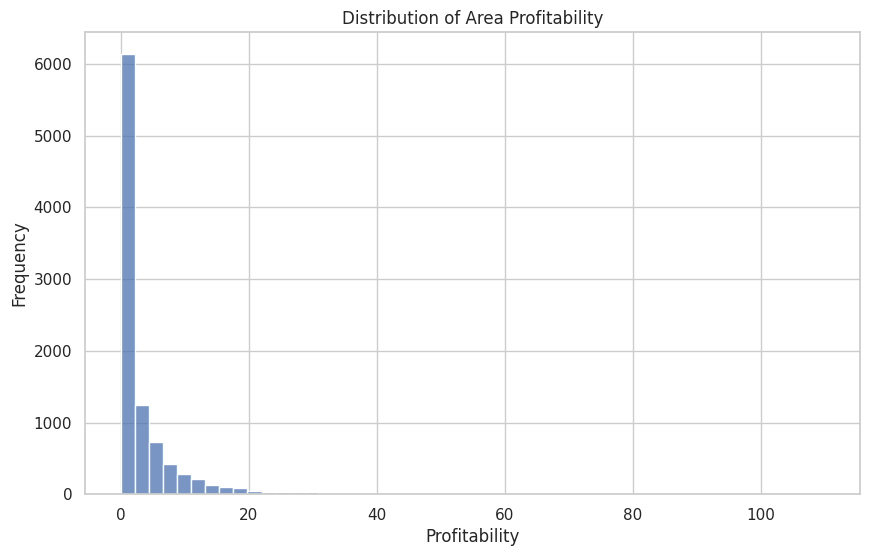

In [77]:
#@title Show histogram of the area profitability data
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(area_profitability_df['profitability'], bins=50)
plt.title('Distribution of Area Profitability')
plt.xlabel('Profitability')
plt.ylabel('Frequency')
plt.show()


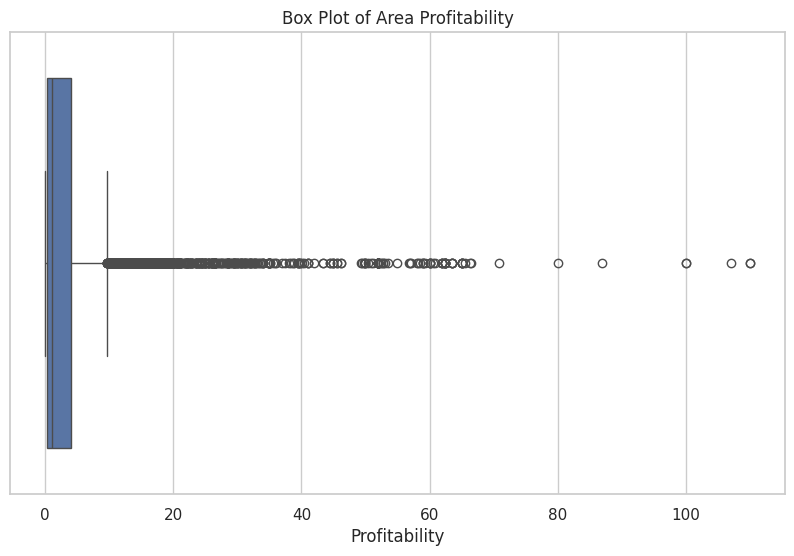

In [78]:
#@title Show the box plot of the area profitability data
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=area_profitability_df['profitability'])
plt.title('Box Plot of Area Profitability')
plt.xlabel('Profitability')
plt.show()

## Observations
### Box plot:
*   **Median and Quartiles**: The box plot clearly indicates that the median profitability is very low, likely at or near zero. The first quartile (Q1) and third quartile (Q3) are also low, reinforcing the observation from the histogram that most areas have low profitability.
*   **Outliers**: The box plot shows a considerable number of individual data points extending far above the upper whisker. These represent significant outliers – areas with exceptionally high profitability compared to the majority.
*   **Spread**: The interquartile range (IQR) is relatively small, indicating that the bulk of the data (the middle 50%) is tightly clustered at lower profitability values.
*   **Interpretation**: The box plot visually confirms the presence of highly profitable hotspots (outliers) that stand out from the vast majority of areas, which exhibit very low or zero profitability. This suggests that identifying and focusing on these high-profitability areas could be crucial for optimizing taxi operations.

### Histogram:
*   **Distribution Shape**: The histogram shows a skewed distribution, heavily concentrated towards lower profitability values, including a significant number of areas with zero profitability.
*   **Concentration at Zero**: A large peak at profitability = 0 indicates many grid areas likely had no trips or no successful trips during the observed time windows, or perhaps the formula resulted in zero for other reasons.
*   **Range**: While many areas have low profitability, there's a long tail extending to higher profitability values, suggesting a few highly profitable areas.
*   **Interpretation**: This implies that profitability is not uniformly distributed across the grid. There are specific areas that are very profitable, while a substantial number of areas yield little to no profit.

## Key findings
The profitability distribution shows the same behaviour as in project 1 without real time data streaming, being heavily skewed, with a significant concentration of areas showing low or zero profitability.
* The large peak at profitability = 0 suggests many grid areas had no trips or no successful trips, or have zero profitability.
* While most areas have low profitability, there is a long tail extending to higher values, which indicates the presence of a few very profitable areas.
* The median profitability is very low, close to zero, and the first and third quartiles are also low, reinforcing the fact that the majority of areas are not very profitable.
* The box plot shows a considerable number of outliers, representing areas with high profitability, significantly above the median and the bulk of the data.
* The interquartile range (IQR) is relatively small, showing that the central 50% of areas are clustered at low profitability levels.

# Q2: How does the trip profitability depend on the trip distance and time of day?

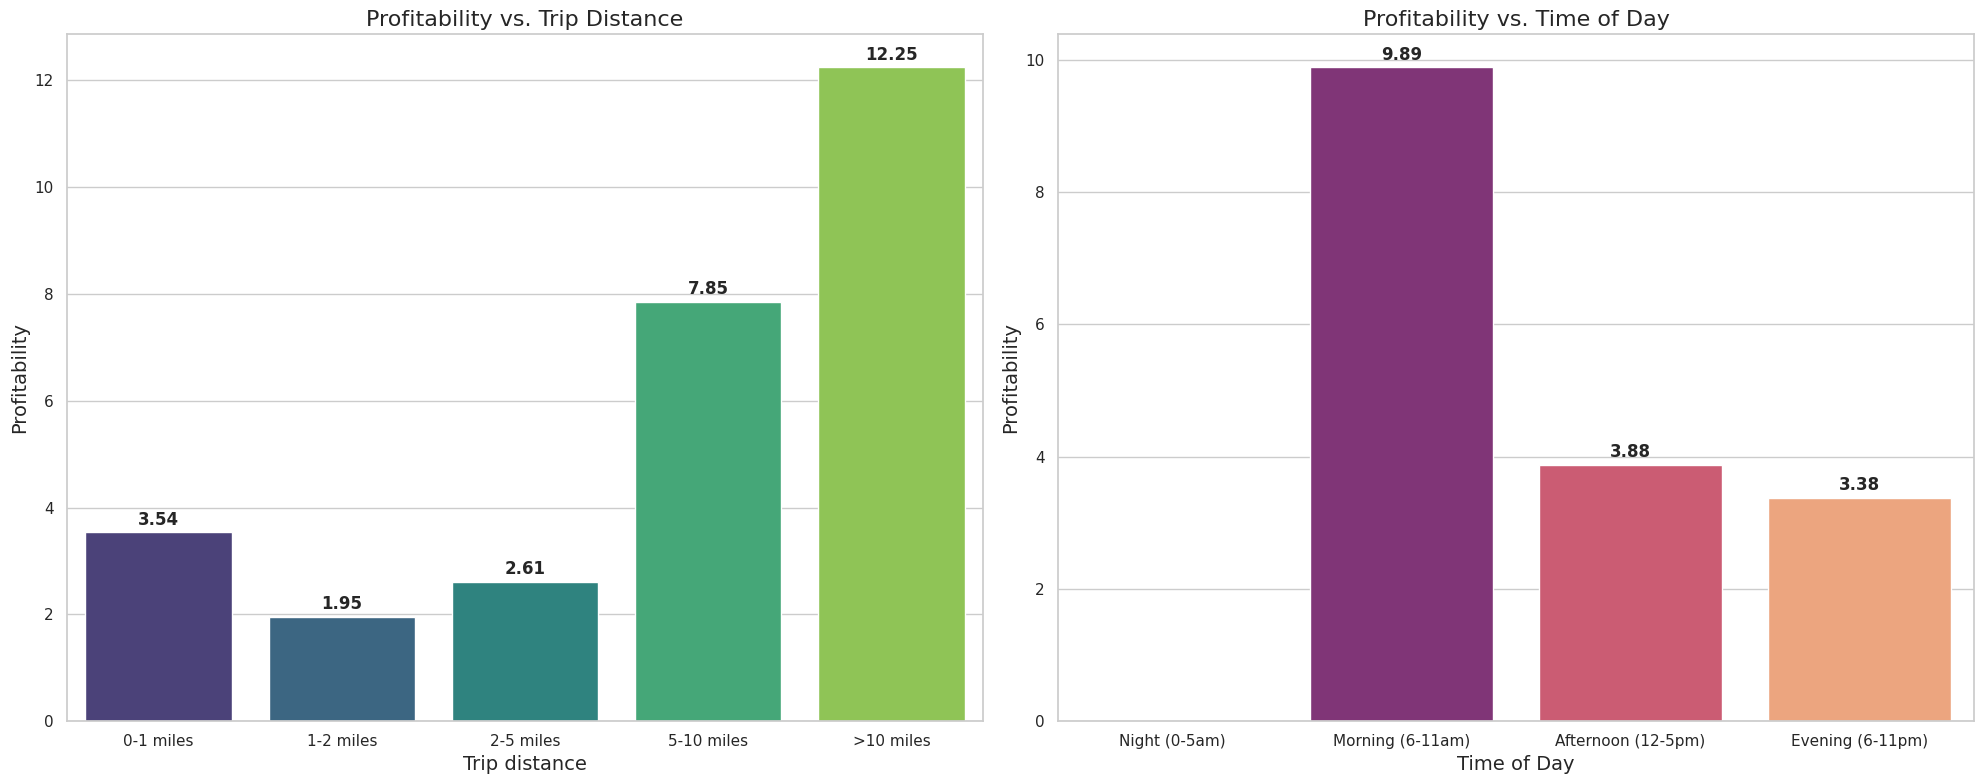

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Define distance bins
dist_bins = [0, 1, 2, 5, 10, 100]
dist_labels = ['0-1 miles', '1-2 miles', '2-5 miles', '5-10 miles', '>10 miles']

# We use .loc to ensure we modify the dataframe correctly
area_profitability_df.loc[:, 'distance_bin'] = pd.cut(
    area_profitability_df['average_trip_distance'],
    bins=dist_bins,
    labels=dist_labels
)

# Setup the dashboard Layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.set_theme(style="whitegrid")

# --- PLOT 1: Profitability vs distance ---
dist_stats = area_profitability_df.groupby('distance_bin', observed=False)['profitability'].mean().reset_index()

sns.barplot(
    data=dist_stats,
    x='distance_bin',
    y='profitability',
    hue='distance_bin',
    palette='viridis',
    legend=False,
    ax=ax1
)
ax1.set_title('Profitability vs. Trip Distance', fontsize=16)
ax1.set_xlabel('Trip distance', fontsize=14)
ax1.set_ylabel('Profitability', fontsize=14)

# Add labels (values on top of bars)
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

# --- PLOT 2: Profitability vs time of day ---
time_order = ["Night (0-5am)", "Morning (6-11am)", "Afternoon (12-5pm)", "Evening (6-11pm)"]
time_stats = area_profitability_df.groupby('time_of_day', observed=False)['profitability'].mean().reindex(time_order).reset_index()

sns.barplot(
    data=time_stats,
    x='time_of_day',
    y='profitability',
    hue='time_of_day',
    palette='magma',
    hue_order=time_order,
    legend=False,
    ax=ax2
)
ax2.set_title('Profitability vs. Time of Day', fontsize=16)
ax2.set_xlabel('Time of Day', fontsize=14)
ax2.set_ylabel('Profitability', fontsize=14)

# Add labels (values on top of bars)
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

## Observations
* **Profitability vs trip distance**: The profitability shows a clear positive trend with the trip distance, with longer trips showing higher profitability. This is exactly the same trend observed in the assessment performed in Project 1 with the historical data, although with different absolute values for each distance bin, which probably has to do with the way the profitability definitions were implemented in the code of Projeto 1 because of the lack of real time knowledge.
* **Profitability vs time of day**: The analysis shows that the profitability of the trips is significantly higher in the morning period (6-11am) than in the afternoon (12-5pm). Surprisingly, even after collecting data for 2h at 60x speed, the profitability remains zero in the night (0-5am) period. The AI Agent was not able to provide any useful guidance or explanation for this issue.

# Addendum - Main interactions with the AI Agent

##1. Question to AI:
The collab environment I am using has `pyspark 4.0.1` installed. However, that version is not compatible with `spark-sql-kafka 3.5.7`. How can I replace `pyspark 4.0.1` with `pyspark 3.5.7`?
##AI answer:
In Google Colab, you can downgrade a pre-installed package by using pip install with a specific version flag. Because PySpark is already loaded into the Python path, you generally need to uninstall the existing version first:

```bash
# Remove the default (unsupported) version
!pip uninstall -y pyspark

# Install the specific compatible version
!pip install pyspark==3.5.7
```

##2. Question to AI:
Change the code to install and lunch the Kafka server to give feedback if the server has started successfuly?
##AI answer:
The following script downloads Kafka (if it does not exist already), installs and starts it, and after 15s checks port 9092 to assess if it started successfuly.

```bash
# Download and Extract Kafka if it doesn't exist
KAFKA_VERSION=3.7.2
KAFKA=kafka_2.12-$KAFKA_VERSION

if [ ! -d "$KAFKA" ]; then
    echo "Kafka not found. Downloading $KAFKA..."
    wget -q https://downloads.apache.org/kafka/$KAFKA_VERSION/$KAFKA.tgz
    tar -xzf $KAFKA.tgz
    rm $KAFKA.tgz
    echo "Download complete."
fi

# Kill any existing Kafka processes
pkill -9 -f kafka || true

# Clear out temporary storage
rm -rf /tmp/kafka-logs /tmp/kraft-combined-logs

# Format and Start
UUID=`$KAFKA/bin/kafka-storage.sh random-uuid`
$KAFKA/bin/kafka-storage.sh format -t $UUID -c $KAFKA/config/kraft/server.properties

# Start Kafka
$KAFKA/bin/kafka-server-start.sh -daemon $KAFKA/config/kraft/server.properties

# Wait for quorum
echo "Waiting for Kafka to start..."
sleep 15

# Verify
lsof -i :9092
```


##3. Question to AI:
Change the code to launch the Kafka publisher to verify that the publisher has strated successfuly and data is being streamed.
##AI answer:
The following script starts the publisher in the background and uses the correct kafka-get-offsets.sh tool to verify data is actually flowing.

```python
#@title Start Kafka publisher & Verify Stream (Fixed for Kafka 3.7.2)
import subprocess
import time
import os

# 1. Install dependencies
!pip --quiet install kafka-python dataclasses

# 2. Setup paths and files
KAFKA_PATH = "/content/kafka_2.12-3.7.2"
if not os.path.exists('kafka-publisher.py'):
    !wget -q -O kafka-publisher.py https://raw.githubusercontent.com/smduarte/spbd-2526/refs/heads/main/docs/labs/projs/kafka-publisher.py

# 3. Start publisher (Redirecting logs for debugging)
print("Starting Kafka publisher...")
!nohup python kafka-publisher.py --topic taxis_json --speedup 120 --filename taxi_rides_1pc.csv.gz > publisher.log 2>&1 &

# 4. Modern Health Check Loop (Replaces GetOffsetShell)
print("Verifying data stream (Waiting for offsets > 0)...")
data_detected = False

for i in range(20): # Try for ~100 seconds
    try:
        # Kafka 3.x tool to get the latest offset (--time -1 means 'latest')
        cmd = [
            f"{KAFKA_PATH}/bin/kafka-get-offsets.sh",
            "--bootstrap-server", "localhost:9092",
            "--topic", "taxis_json",
            "--time", "-1"
        ]
        
        output = subprocess.check_output(cmd, stderr=subprocess.STDOUT).decode()
        
        # Output format: taxis_json:0:OFFSETS
        if ":" in output:
            # Extract the offset (the last number after the last colon)
            current_offset = int(output.strip().split(':')[-1])
            
            if current_offset > 0:
                print(f"✅ Success! Kafka is streaming. Current offset: {current_offset}")
                data_detected = True
                break
    except Exception as e:
        # This handles cases where the topic isn't created yet or broker is warming up
        pass
    
    print(f"Waiting for data... ({i+1}/20)")
    time.sleep(5)

if not data_detected:
    print("❌ ERROR: No data detected. Showing last 10 lines of publisher.log:")
    !tail -n 10 publisher.log
```

##4. Question to AI:
In the area profitability visualization, I would like to highlight the area with the highest profitability. How can I do that?
##AI answer:
Add the following code at the end of your visualization code.

```python
# Highlight the "Best" grid cell
best_row = geo_df.loc[geo_df['max_profit'].idxmax()]
plt.annotate(f"Highest Profitability Grid\n({best_row['grid_x']}, {best_row['grid_y']})",
             xy=(best_row['grid_x'], best_row['grid_y']),
             xytext=(best_row['grid_x']+2, best_row['grid_y']+2),
             arrowprops=dict(facecolor='white', shrink=0.05, width=1))
```

##5. Question to AI:
What changes do I need to do to my data stream preparation code to be able to assess how the profitability depends on the time of day of the trip. Consider the time of day divided into four bins: night (0-5am), morning (6am-11am), afternoon (12pm-17pm), and evening (18pm-23pm).
##AI answer:
To assess profitability by time of day, you need to extract the hour from your pickup timestamps within Spark, group the data into your four specific bins, and then carry that "Time Bin" through your joins.

Here is the exact modification for your code.
```python
from pyspark.sql.functions import hour, col, floor, when

processed_stream = structured_stream \
    .withColumn("pickup_grid_x", floor((MAX_LAT - col("pickup_latitude")) / LAT_DELTA)) \
    .withColumn("pickup_grid_y", floor((col("pickup_longitude") - MIN_LON) / LON_DELTA)) \
    .withColumn("dropoff_grid_x", floor((MAX_LAT - col("dropoff_latitude")) / LAT_DELTA)) \
    .withColumn("dropoff_grid_y", floor((col("dropoff_longitude") - MIN_LON) / LON_DELTA)) \
    .filter(
        (col("pickup_latitude").isNotNull()) & (col("pickup_longitude").isNotNull()) & \
        (col("dropoff_latitude").isNotNull()) & (col("dropoff_longitude").isNotNull()) & \
        (col("pickup_grid_x").between(0, 299)) & (col("pickup_grid_y").between(0, 299)) & \
        (col("dropoff_grid_x").between(0, 299)) & (col("dropoff_grid_y").between(0, 299)) & \
        (col("trip_distance") > 0)
    ) \
    .withColumn("trip_profit", col("fare_amount") + col("tip_amount")) \
    .withColumn("pickup_hour", hour(col("pickup_datetime"))) \
    .withColumn("time_of_day",
        when((col("pickup_hour") >= 0) & (col("pickup_hour") <= 5), "Night (0-5am)")
        .when((col("pickup_hour") >= 6) & (col("pickup_hour") <= 11), "Morning (6-11am)")
        .when((col("pickup_hour") >= 12) & (col("pickup_hour") <= 17), "Afternoon (12-5pm)")
        .otherwise("Evening (6-11pm)")
    )
```

You also need to add `time_of_day` to `average_profit_per_area_stream`, `area_metrics_stream`, and `area_profitability` as well.

##6. Question to AI:
I want to display the plots of the profitability vs trip distance and of the profitability vs time of day side-by-side. How can I do that?
##AI answer:
Here is the consolidated dashboard code. This cell will pull your collected data and generate two distinct visualizations side-by-side: one for Trip Distance and one for Time of Day. This allows you to see at a glance if distance or timing is the bigger driver of profitability in your simulation.

```python
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Pull the data from the memory sink
pdf = spark.sql("SELECT * FROM collected_data").toPandas()

if pdf.empty:
    print("Dashboard empty: Ensure your streaming query is running and data is flowing.")
else:
    # 2. Data Preparation for Distance Bins
    dist_bins = [0, 2, 5, 10, 100]
    dist_labels = ['Short (0-2mi)', 'Medium (2-5mi)', 'Long (5-10mi)', 'Ultra (10mi+)']
    pdf['distance_bin'] = pd.cut(pdf['average_trip_distance'], bins=dist_bins, labels=dist_labels)
    
    # 3. Create the Dashboard (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # --- PLOT 1: PROFITABILITY BY DISTANCE ---
    dist_analysis = pdf.groupby('distance_bin', observed=False)['profitability'].mean().reset_index()
    sns.barplot(data=dist_analysis, x='distance_bin', y='profitability', palette='viridis', ax=ax1)
    ax1.set_title('Profitability by Trip Distance', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Mean Profitability Score')
    ax1.set_xlabel('Distance Category')
    
    # Add values on top of bars
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    # --- PLOT 2: PROFITABILITY BY TIME OF DAY ---
    # Reindex to ensure chronological order
    time_order = ["Night (0-5am)", "Morning (6-11am)", "Afternoon (12-5pm)", "Evening (6-11pm)"]
    time_analysis = pdf.groupby('time_of_day', observed=False)['profitability'].mean().reindex(time_order).reset_index()
    
    sns.barplot(data=time_analysis, x='time_of_day', y='profitability', palette='coolwarm', ax=ax2)
    ax2.set_title('Profitability by Time of Day', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Mean Profitability Score')
    ax2.set_xlabel('Time Period')
    
    # Add values on top of bars
    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    plt.tight_layout()
    plt.show()
```